# Project 2

This project utilizes *openml* to read the dataset.

In [5]:
import openml
import pandas as pd

# 1. Fetch the dataset using its ID
dataset = openml.datasets.get_dataset(31)

# 2. Get the data, specifying 'class' as the target variable
X, y, categorical_indicator, attribute_names = dataset.get_data(target="class")

df = pd.concat([X, y], axis=1)

## Data Preparation

The first step in perparing the data involes splitting the dataset into a test and training set.

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 800
Testing set size: 200


In [7]:
# Display the first few rows
print(X.head())

# Check for data types and missing values
print(X.info())

# Statistical summary of numerical features
print(X.describe())

  checking_status  duration                  credit_history  \
0              <0         6  critical/other existing credit   
1        0<=X<200        48                   existing paid   
2     no checking        12  critical/other existing credit   
3              <0        42                   existing paid   
4              <0        24              delayed previously   

               purpose  credit_amount    savings_status employment  \
0             radio/tv         1169.0  no known savings        >=7   
1             radio/tv         5951.0              <100     1<=X<4   
2            education         2096.0              <100     4<=X<7   
3  furniture/equipment         7882.0              <100     4<=X<7   
4              new car         4870.0              <100     1<=X<4   

   installment_commitment     personal_status other_parties  residence_since  \
0                       4         male single          none                4   
1                       2  female div/de

This output shows an overview of the German Credit dataset. This contains 1,000 entries across 20 different attributes. It includes a mix of categorical and numerical data types. 

#### Checking for missing values.

In [8]:
# Check for null values
print(X.isnull().sum())

checking_status           0
duration                  0
credit_history            0
purpose                   0
credit_amount             0
savings_status            0
employment                0
installment_commitment    0
personal_status           0
other_parties             0
residence_since           0
property_magnitude        0
age                       0
other_payment_plans       0
housing                   0
existing_credits          0
job                       0
num_dependents            0
own_telephone             0
foreign_worker            0
dtype: int64


This shows there is no missing values in the dataset. 

#### Understanding the target variable.

In [9]:
# Check class distribution
print(y.value_counts(normalize=True))

class
good    0.7
bad     0.3
Name: proportion, dtype: float64


This shows us that the dataset is imbalanced with 70% having good credit, and 30% having bad credit.

### Visualizing the Dataset

To help understand the data, we use boxplots and histograms to get a better representation of the content in the dataset. This allows us to check for outliers and get more insight into the distribuion inside the dataset. First, looking at the histograms:

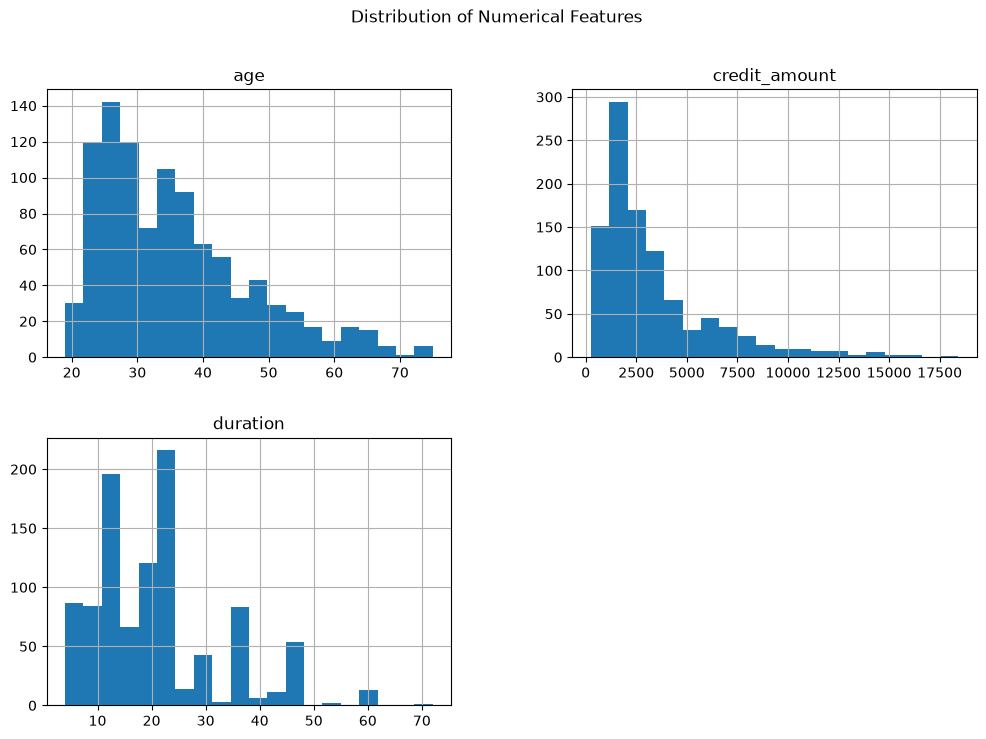

In [10]:
import matplotlib.pyplot as plt

# Select numerical columns
num_cols = ['age', 'credit_amount', 'duration']

# Plot histograms
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle('Distribution of Numerical Features')
plt.show()

The histograms illustrate that the **age** and **credit_amount** features exhibit a right-skewed distribution, showing that the majority of applicants are younger and request smaller loan amounts. Next, we examine the boxplots to check for outliers:

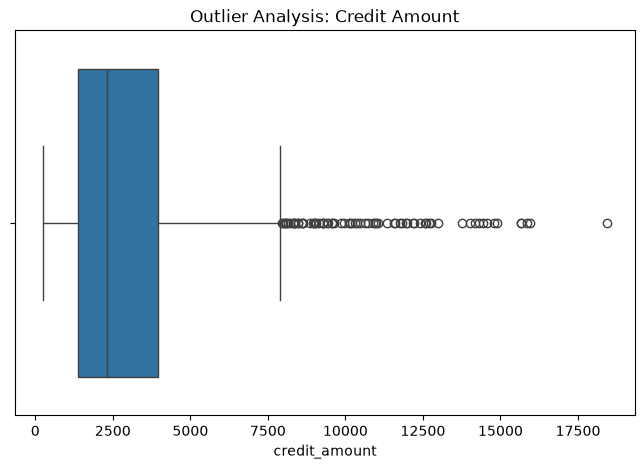

In [12]:
import seaborn as sns

# Boxplot for credit_amount
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['credit_amount'])
plt.title('Outlier Analysis: Credit Amount')
plt.show()

The boxplot reveals that the **credit_amount** feature is positively skewed, with a majority of loans concentrated at lower values.

Looking for correlations between attributes.

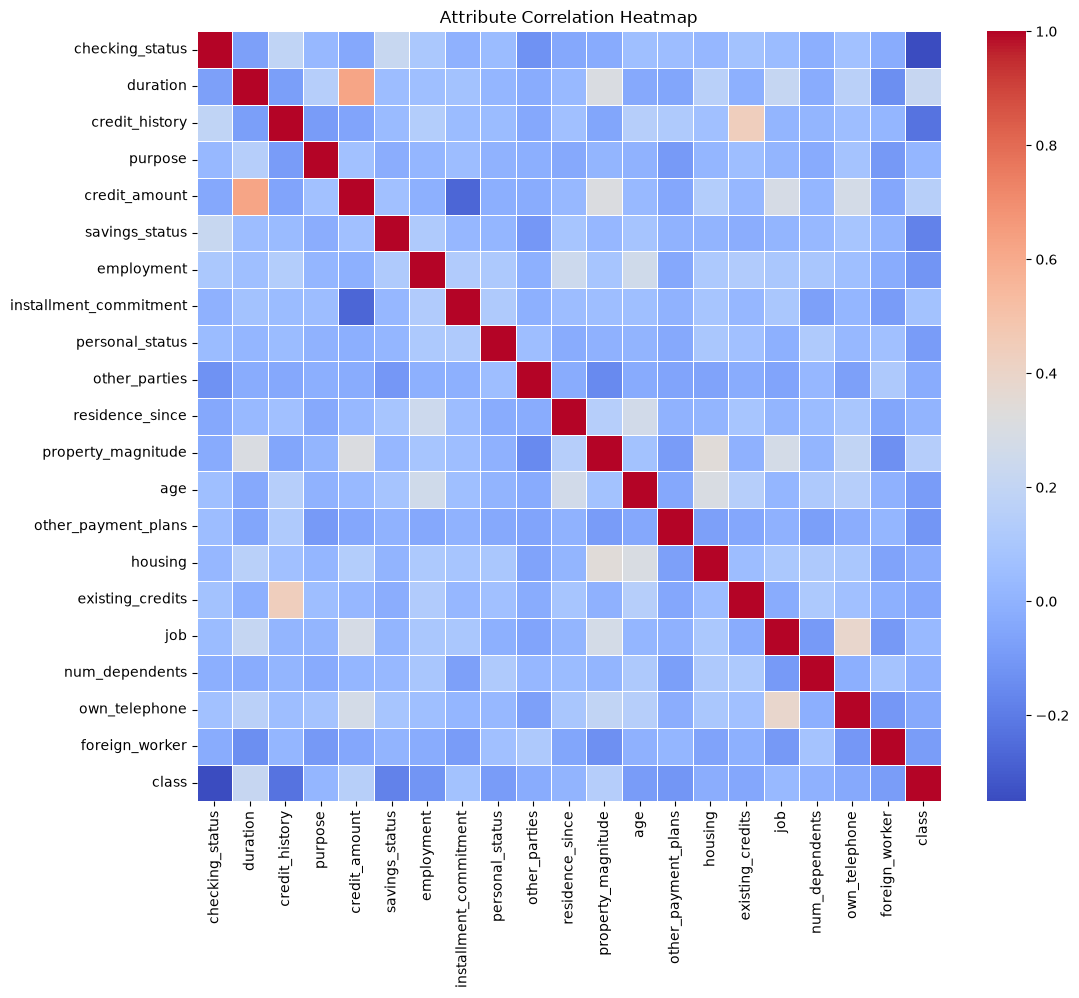

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Encode categorical features temporarily for correlation analysis
df_encoded = df.copy()
for col in df_encoded.select_dtypes(['category', 'object']).columns:
    df_encoded[col] = df_encoded[col].cat.codes

# 2. Calculate the correlation matrix
corr_matrix = df_encoded.corr()

# 3. Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Attribute Correlation Heatmap')
plt.show()

### Preprocessing the Data

To prepare the dataset for machine learning we utilize a ColumnTransformer to standardize all the numerical features and apply one-hot encoding on all of the categorical features. This dual approach helps ensure that the features are correctly scaled and numerically represented for a consistent input for the model.

In [14]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Identify feature types
numeric_features = ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
categorical_features = ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']

# 2. Define the transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# 3. Fit and transform the data (using the training set)
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

## Model Selection

Several classification algorithms are compared using cross-validation. Since the dataset is imbalanced, the weighted F1-score is used to select the best overall model.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import pandas as pd

# Candidate classification algorithms for credit risk prediction.
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=42),
    "Support Vector Machine": SVC(class_weight="balanced", random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]

model_results = []
for model_name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    model_results.append({
        "Model": model_name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision_weighted"].mean(),
        "Recall": scores["test_recall_weighted"].mean(),
        "F1 Score": scores["test_f1_weighted"].mean()
    })

results_df = pd.DataFrame(model_results).sort_values(by="F1 Score", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["Model"]
print(f"Selected model: {best_model_name}")


,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.75500,0.754722,0.75500,0.753160
3,Support Vector Machine,0.73750,0.763930,0.73750,0.743994
0,Logistic Regression,0.73375,0.767528,0.73375,0.742479
1,Decision Tree,0.67000,0.673308,0.67000,0.670046


Selected model: Random Forest


## Model Training

The selected model is trained on the full training dataset so it can learn the relationship between applicant features and credit-risk category.

In [16]:
best_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", models[best_model_name])
])

best_model.fit(X_train, y_train)

print(f"{best_model_name} has been trained on the full training dataset.")


Random Forest has been trained on the full training dataset.


## Model Evaluation

The trained model is evaluated on the unseen test set using accuracy, precision, recall, F1-score, and ROC-AUC.

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import LabelEncoder

# Predict credit-risk classes for the test data.
y_pred = best_model.predict(X_test)

# Get continuous scores for ROC-AUC.
classifier = best_model.named_steps["classifier"]
if hasattr(best_model, "predict_proba"):
    class_labels = list(classifier.classes_)
    positive_label = "bad" if "bad" in class_labels else class_labels[1]
    positive_index = class_labels.index(positive_label)
    y_scores = best_model.predict_proba(X_test)[:, positive_index]
elif hasattr(best_model, "decision_function"):
    class_labels = list(classifier.classes_)
    positive_label = "bad" if "bad" in class_labels else class_labels[1]
    y_scores = best_model.decision_function(X_test)
    if class_labels[1] != positive_label:
        y_scores = -y_scores
else:
    class_labels = sorted(y_test.unique())
    positive_label = "bad" if "bad" in class_labels else class_labels[1]
    y_scores = y_pred

# Convert target labels to binary values for ROC-AUC.
y_test_binary = (y_test == positive_label).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
roc_auc = roc_auc_score(y_test_binary, y_scores)

evaluation_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, roc_auc]
})

display(evaluation_results)

print("Confusion Matrix:")
display(pd.DataFrame(
    confusion_matrix(y_test, y_pred),
    index=[f"Actual {label}" for label in classifier.classes_],
    columns=[f"Predicted {label}" for label in classifier.classes_]
))

print("Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))


,Metric,Score
0,Accuracy,0.720000
1,Precision,0.731551
2,Recall,0.720000
3,F1 Score,0.724632
4,ROC-AUC,0.798274


Confusion Matrix:


,Predicted bad,Predicted good
Actual bad,36,24
Actual good,32,108


Classification Report:
              precision    recall  f1-score   support

         bad       0.53      0.60      0.56        60
        good       0.82      0.77      0.79       140

    accuracy                           0.72       200
   macro avg       0.67      0.69      0.68       200
weighted avg       0.73      0.72      0.72       200



## Hyperparameter Tuning

In [18]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid for Random Forest
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 5, 10, 15],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

# Build a fresh pipeline to tune (same structure as best_model)
tuning_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=42))
])

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters found:")
print(grid_search.best_params_)
print(f"\nBest cross-validated F1 score: {grid_search.best_score_:.4f}")

# The tuned model
tuned_model = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters found:
{'classifier__max_depth': 15, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}

Best cross-validated F1 score: 0.7659


Hyperparameter tuning improved the cross-validated F1 score from 0.7532 (default Random Forest) to 0.7659, with the best configuration favoring a moderate tree depth (15), a larger ensemble (300 trees), and the log2 feature subset size

### Re-evaluating the tuned model

In [19]:
# Predict with the tuned model
y_pred_tuned = tuned_model.predict(X_test)

tuned_classifier = tuned_model.named_steps["classifier"]
y_scores_tuned = tuned_model.predict_proba(X_test)[:, positive_index]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned, average="weighted", zero_division=0)
recall_tuned = recall_score(y_test, y_pred_tuned, average="weighted", zero_division=0)
f1_tuned = f1_score(y_test, y_pred_tuned, average="weighted", zero_division=0)
roc_auc_tuned = roc_auc_score(y_test_binary, y_scores_tuned)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    "Before Tuning": [accuracy, precision, recall, f1, roc_auc],
    "After Tuning": [accuracy_tuned, precision_tuned, recall_tuned, f1_tuned, roc_auc_tuned]
})

display(comparison_df)

print("Confusion Matrix (Tuned Model):")
display(pd.DataFrame(
    confusion_matrix(y_test, y_pred_tuned),
    index=[f"Actual {label}" for label in tuned_classifier.classes_],
    columns=[f"Predicted {label}" for label in tuned_classifier.classes_]
))

print("Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned, zero_division=0))

,Metric,Before Tuning,After Tuning
0,Accuracy,0.720000,0.725000
1,Precision,0.731551,0.737969
2,Recall,0.720000,0.725000
3,F1 Score,0.724632,0.730027
4,ROC-AUC,0.798274,0.775476


Confusion Matrix (Tuned Model):


,Predicted bad,Predicted good
Actual bad,37,23
Actual good,32,108


Classification Report (Tuned Model):
              precision    recall  f1-score   support

         bad       0.54      0.62      0.57        60
        good       0.82      0.77      0.80       140

    accuracy                           0.72       200
   macro avg       0.68      0.69      0.69       200
weighted avg       0.74      0.72      0.73       200



## Predictions

With the tuned Random Forest model finalized, we now generate credit-risk predictions for each applicant in the test set

In [20]:
# 6. Prediction
# Use the tuned model to predict credit risk for the test applicants

# Predicted class labels
predictions = tuned_model.predict(X_test)

# Predicted probability of being "bad" credit risk
bad_probabilities = tuned_model.predict_proba(X_test)[:, positive_index]

# Build a results table combining key applicant info with predictions
results = X_test.copy()
results["Actual Credit Risk"] = y_test.values
results["Predicted Credit Risk"] = predictions
results["Predicted Probability (Bad)"] = bad_probabilities.round(3)

# Reset index for cleaner display
results = results.reset_index(drop=True)

print(f"Total applicants in test set: {len(results)}")
print(f"Predicted as 'bad' credit risk: {(results['Predicted Credit Risk'] == 'bad').sum()}")
print(f"Predicted as 'good' credit risk: {(results['Predicted Credit Risk'] == 'good').sum()}")

# Show a sample of predictions
results[["checking_status", "duration", "credit_amount", "age",
         "Actual Credit Risk", "Predicted Credit Risk", "Predicted Probability (Bad)"]].head(10)

Total applicants in test set: 200
Predicted as 'bad' credit risk: 69
Predicted as 'good' credit risk: 131


,checking_status,duration,credit_amount,age,Actual Credit Risk,Predicted Credit Risk,Predicted Probability (Bad)
0,0<=X<200,18,2427.0,42,good,good,0.248
1,0<=X<200,36,3990.0,29,good,bad,0.645
2,0<=X<200,48,12204.0,48,good,bad,0.509
3,no checking,10,1597.0,40,good,good,0.271
4,0<=X<200,36,12389.0,37,bad,good,0.423
5,>=200,12,409.0,42,good,good,0.464
6,no checking,24,2255.0,54,good,good,0.179
7,<0,18,2600.0,65,bad,bad,0.552
8,<0,18,3114.0,26,bad,bad,0.606
9,no checking,15,1569.0,34,good,good,0.393


Out of 200 test applicants, the model predicted 69 as "bad" credit risk and 131 as "good" slightly more than the 60 actual "bad" cases

In [21]:
# Highlight the highest-risk applicants (highest predicted probability of "bad")
highest_risk = results.sort_values("Predicted Probability (Bad)", ascending=False).head(5)
print("Top 5 highest-risk applicants (by predicted probability):")
display(highest_risk[["checking_status", "duration", "credit_amount", "age",
                       "Actual Credit Risk", "Predicted Credit Risk", "Predicted Probability (Bad)"]])

Top 5 highest-risk applicants (by predicted probability):


,checking_status,duration,credit_amount,age,Actual Credit Risk,Predicted Credit Risk,Predicted Probability (Bad)
96,0<=X<200,30,4249.0,28,bad,bad,0.826
29,0<=X<200,36,14318.0,57,bad,bad,0.801
97,<0,24,1442.0,23,bad,bad,0.791
68,<0,18,1553.0,44,bad,bad,0.770
159,<0,12,652.0,24,good,bad,0.765


Four of the five highest-risk predictions match the actual label, and all five applicants share a negative or low checking account balance, suggesting checking status is a strong driver of the model's risk assessment.

In [22]:
# Cases where the model disagreed with the actual label — useful for later interpretation
misclassified = results[results["Actual Credit Risk"] != results["Predicted Credit Risk"]]
print(f"Number of misclassified applicants: {len(misclassified)} out of {len(results)}")
misclassified[["checking_status", "duration", "credit_amount", "age",
               "Actual Credit Risk", "Predicted Credit Risk", "Predicted Probability (Bad)"]].head(10)

Number of misclassified applicants: 55 out of 200


,checking_status,duration,credit_amount,age,Actual Credit Risk,Predicted Credit Risk,Predicted Probability (Bad)
1,0<=X<200,36,3990.0,29,good,bad,0.645
2,0<=X<200,48,12204.0,48,good,bad,0.509
4,0<=X<200,36,12389.0,37,bad,good,0.423
11,no checking,9,1980.0,19,bad,good,0.309
17,no checking,24,4591.0,54,bad,good,0.249
21,0<=X<200,12,6468.0,52,bad,good,0.337
22,0<=X<200,18,1245.0,33,bad,good,0.410
25,no checking,48,6110.0,31,good,bad,0.626
36,>=200,36,3913.0,23,good,bad,0.539
37,>=200,15,2327.0,25,bad,good,0.411


The misclassifications include both false negatives, where applicants with a *"no checking"* status were predicted as low risk despite being actually bad, and false positives, where longer loan durations and larger credit amounts pushed otherwise good applicants into the *"bad"* risk category

## Interpertation

#### Data Preparation:

The dataset for training was 800 samples, whereas the testing set was 200 samples. The training set was used purely for train the model, and the testing set was used for evaluating performance later. Missing values were checked for, none were found. Dataset is skewed towards the good credit side, 70% of the set being as such. 

#### Dataset Visualization: 

Most applicants are between 20 and 40, and the credit credit amount is heavily skewed towards the small loans side. Related, the durations trend shorter. The heatmap shows little correlation between attributes. 

#### Model Selection: 

Four different algorithms were checked, those being Random Forest, Support Vector Machine, Logistic Regression, and Decision Tree. Each one was measured by accuracy, precision, recall, and F1 scores. Since Random Forest got the highest scores for the different measurements (except accuracy against SVM), that was chosen for the model. 

#### Model Evaluation:

Using accuracy, precision, recall, F1 score, and ROC-AUC, we were able to evaluate the Random Forest model, and the scores showed a solid ability to distinguish between good and bad credit risks. The confusion matrix backed this up. The model is better at classifying good credit as opposed to spotting bad credit risks.

#### Hyperparameter Tuning:

Using GridSearchCV, the model was tuned to find the best fitting configuration. The best performing model used 300 decision trees, and had a max depth of 15. Post tuning, the model showed a small increase in performance across the board, aside from ROC-AUC which ended up decreasing slightly. The other categories only changed within a tenth of a percentage point. 

#### Predictions: 

The model was used to predict the credit risk of 200 applicants in the test dataset. Of these, 69 applicants were classified as bad credit risks, while 131 applicants were classified as good. The model identified the five highest risk applicants based on the predicted probability of being a bad credit risk. Four of these applicants were correctly identified as bad credit risks, while one applicant was incorrectly classified as bad despite actually being good. This shows that the model is generally effective at identifying applicants with the greatest likelihood of default. The prediction results also identified 55 misclassified applicants out of 200, meaning the model correctly classified 145 applicants.
